<a href="https://colab.research.google.com/github/PandaX187/OcuTriage/blob/main/OcuTriage_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Updated path based on your sidebar screenshot
!unzip -q "/content/drive/MyDrive/OcuTriage_Project/Dataset/train_images.zip" -d "/content/dataset"

In [ ]:
import pandas as pd
import os
import shutil

# 1. Set your paths based on your sidebar screenshot
# We use the folder inside OcuTriage_Project where your CSV is
base_path = '/content/drive/MyDrive/OcuTriage_Project/Dataset/'
csv_path = os.path.join(base_path, 'train.csv')
unzipped_images = '/content/dataset/train_images/' # This is where we just unzipped them

# 2. Create the Traffic Light folders in your Drive
categories = ['Green_No_DR', 'Yellow_Mild_Moderate', 'Red_Severe_Proliferative']
for cat in categories:
    os.makedirs(os.path.join(base_path, cat), exist_ok=True)

# 3. Load the labels
df = pd.read_csv(csv_path)

print("Starting to sort images into Traffic Light categories...")

# 4. Loop through and copy files
for index, row in df.iterrows():
    img_name = row['id_code'] + '.png'
    diagnosis = row['diagnosis']

    # Traffic Light Logic based on severity grades 0-4
    if diagnosis == 0:
        dest_folder = categories[0] # Green
    elif diagnosis in [1, 2]:
        dest_folder = categories[1] # Yellow
    else:
        dest_folder = categories[2] # Red

    src = os.path.join(unzipped_images, img_name)
    dst = os.path.join(base_path, dest_folder, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)

print("✅ Task 1.1 Complete! Check your Google Drive 'Dataset' folder.")

Starting to sort images into Traffic Light categories...
✅ Task 1.1 Complete! Check your Google Drive 'Dataset' folder.


In [ ]:

!pip install split-folders

import splitfolders


input_folder = '/content/drive/MyDrive/OcuTriage_Project/Dataset/'
output_folder = '/content/drive/MyDrive/OcuTriage_Project/Final_Split_Data/'

# Split with a ratio of (train, val, test)
# 0.8 = 80%, 0.1 = 10%, 0.1 = 10%
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 3662 files [10:03,  6.07 files/s]


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# 1. Mount and Load Data (Make sure paths are correct)
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/OcuTriage_Project/Final_Split_Data/train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/OcuTriage_Project/Final_Split_Data/val',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# 2. Build EfficientNet-B0 with Transfer Learning
# This is fast because we 'freeze' the base layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.2), # Prevents the model from 'memorizing'
    layers.Dense(3, activation='softmax') # Green, Yellow, Red
])

# 3. Compile and Run
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Start with 10 Epochs to see the progress
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Found 2929 files belonging to 3 classes.
Found 364 files belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 750s 8s/step - accuracy: 0.7644 - loss: 0.5820 - val_accuracy: 0.8187 - val_loss: 0.5104
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.8395 - loss: 0.3923 - val_accuracy: 0.8626 - val_loss: 0.4044
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.8607 - loss: 0.3602 - val_accuracy: 0.8819 - val_loss: 0.3443
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.8607 - loss: 0.3322 - val_accuracy: 0.8846 - val_loss: 0.3024
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 279s 3s/step - accuracy: 0.8836 - loss: 0.2971 - val_accuracy: 0.8901 - val_loss: 0.2908
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.8846 - loss: 0.3012 - val_accuracy: 0.8874 - val_loss: 0.2787
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.8849 - loss: 0.2950 - val_accuracy: 0.890

In [4]:
model.save('/content/drive/MyDrive/OcuTriage_Project/ocutriage_model_v1.keras')
print("Native Keras model saved as well!")

Native Keras model saved as well!


In [4]:
import tensorflow as tf
# Use the .keras extension to match the save you just made
model_path = '/content/drive/MyDrive/OcuTriage_Project/ocutriage_model_v1.keras'
model = tf.keras.models.load_model(model_path)

print("✅ Model loaded successfully! Now running summary...")
model.summary()

✅ Model loaded successfully! Now running summary...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,064,939 (15.51 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 6,405 (25.02 KB)

In [8]:
!pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00


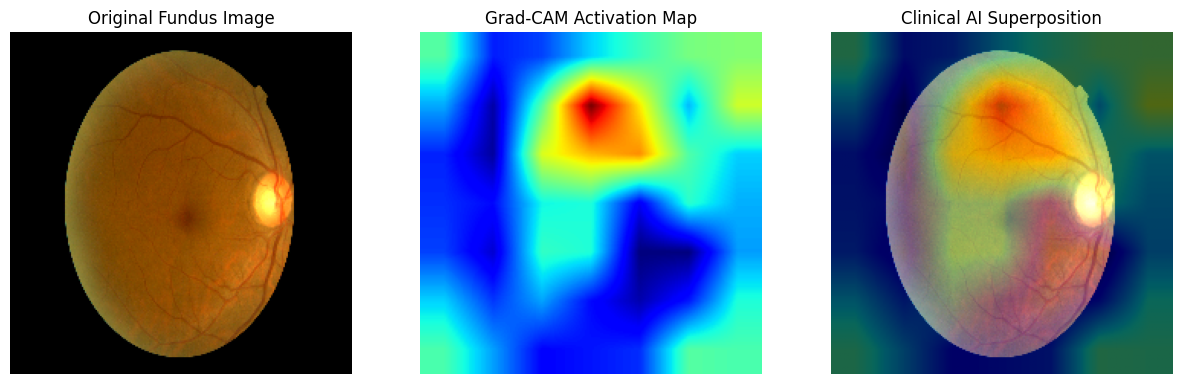

In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# Pointed to your Red image
test_img_path = '/content/drive/MyDrive/OcuTriage_Project/Final_Split_Data/test/Green_No_DR/10de500cf0c5.png'

def generate_clinical_gradcam(img_array, model):
    feature_extractor = model.get_layer("efficientnetb0")
    classifier_layers = model.layers[1:]

    with tf.GradientTape() as tape:
        feature_maps = feature_extractor(img_array)
        tape.watch(feature_maps)

        x = feature_maps
        # Run through all layers EXCEPT the final Dense layer (to avoid Softmax flattening)
        for layer in classifier_layers[:-1]:
            x = layer(x)

        # Manually calculate the raw logits (Pre-Softmax)
        final_dense = classifier_layers[-1]
        logits = tf.matmul(x, final_dense.kernel) + final_dense.bias

        top_pred_index = tf.argmax(logits[0])
        top_class_channel = logits[:, top_pred_index]

    # Calculate gradients based on the raw, un-squashed data
    grads = tape.gradient(top_class_channel, feature_maps)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    output = feature_maps[0]
    heatmap = tf.reduce_sum(tf.multiply(weights, output), axis=-1)

    # Filter and Normalize
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap

# --- CLINICAL VISUALIZATION ---

img_raw = tf.keras.utils.load_img(test_img_path, target_size=(224, 224))
img_tensor = tf.keras.utils.img_to_array(img_raw)

# THE CRITICAL FIX: No "/ 255.0" here! We feed it the raw 0-255 pixels.
img_tensor = np.expand_dims(img_tensor, axis=0)

# Generate Map
heatmap = generate_clinical_gradcam(img_tensor, model)

# Resize & Colorize
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_rescaled = np.uint8(255 * heatmap_resized)
jet = plt.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_rescaled]

# We only divide by 255 here so matplotlib can display the original image properly
original = cv2.imread(test_img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224)) / 255.0

superimposed_img = jet_heatmap * 0.4 + original
superimposed_img = np.clip(superimposed_img, 0, 1)

# Display Output
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.title("Original Fundus Image")
plt.imshow(original)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Activation Map")
plt.imshow(heatmap_resized, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Clinical AI Superposition")
plt.imshow(superimposed_img)
plt.axis('off')
plt.show()